# 03 — Modèles Machine Learning

**Modèles entraînés** : Logistic Regression, Random Forest, Gradient Boosting, SVM, KNN, XGBoost  
**Données** : X_train/X_test depuis `data/processed/` (preprocessées, équilibrées par SMOTE)


### 1 - Chargement & vue d'ensemble 

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path

from sklearn.linear_model    import LogisticRegression
from sklearn.ensemble        import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm             import SVC
from sklearn.neighbors       import KNeighborsClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.metrics         import (
    accuracy_score, roc_auc_score, roc_curve,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print('XGBoost non installé (pip install xgboost)')

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

PROC_PATH  = Path('../data/processed')
ML_PATH    = Path('../models/ml')
FIGS_PATH  = Path('../reports/figures')
ML_PATH.mkdir(parents=True, exist_ok=True)

# Chargement
X_train = np.load(PROC_PATH / 'X_train.npy')
X_test  = np.load(PROC_PATH / 'X_test.npy')
y_train = np.load(PROC_PATH / 'y_train.npy')
y_test  = np.load(PROC_PATH / 'y_test.npy')
feat_names = np.load(PROC_PATH / 'feature_names.npy', allow_pickle=True)

print(f'X_train : {X_train.shape}  y_train : {y_train.shape}')
print(f'X_test  : {X_test.shape}   y_test  : {y_test.shape}')
print(f'Ratio malades test : {y_test.mean():.3f}')

X_train : (814, 26)  y_train : (814,)
X_test  : (184, 26)   y_test  : (184,)
Ratio malades test : 0.554


In [2]:
print('--- Types ---')
print(df_raw.dtypes)
print()
print('--- Valeurs uniques (catégorielles) ---')
for col in ['sex', 'cp', 'restecg', 'slope', 'thal', 'dataset', 'fbs', 'exang']:
    print(f'  {col:12s}: {list(df_raw[col].dropna().unique())}')

--- Types ---
id            int64
age           int64
sex          object
dataset      object
cp           object
trestbps    float64
chol        float64
fbs          object
restecg      object
thalch      float64
exang        object
oldpeak     float64
slope        object
ca          float64
thal         object
num           int64
dtype: object

--- Valeurs uniques (catégorielles) ---
  sex         : ['Male', 'Female']
  cp          : ['typical angina', 'asymptomatic', 'non-anginal', 'atypical angina']
  restecg     : ['lv hypertrophy', 'normal', 'st-t abnormality']
  slope       : ['downsloping', 'flat', 'upsloping']
  thal        : ['fixed defect', 'normal', 'reversable defect']
  dataset     : ['Cleveland', 'Hungary', 'Switzerland', 'VA Long Beach']
  fbs         : [True, False]
  exang       : [False, True]


### 2 - Définition des modèles

In [10]:
MODELS = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=200, random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=200, random_state=42),
    'SVM':                 SVC(probability=True, kernel='rbf', random_state=42),
    'KNN':                 KNeighborsClassifier(n_neighbors=7),
}
if HAS_XGB:
    MODELS['XGBoost'] = XGBClassifier(
        n_estimators=200, eval_metric='logloss',
        use_label_encoder=False, random_state=42
    )

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print(f'{len(MODELS)} modèles définis : {list(MODELS.keys())}')

6 modèles définis : ['Logistic Regression', 'Random Forest', 'Gradient Boosting', 'SVM', 'KNN', 'XGBoost']


### 3 - Entraînement & évaluation cross-validation

In [12]:
results = []
trained_models = {}

for name, model in MODELS.items():
    print(f'\n--- {name} ---')

    # Cross-validation sur le train set
    cv_acc = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy')
    cv_auc = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc')
    print(f'  CV Accuracy : {cv_acc.mean():.4f} ± {cv_acc.std():.4f}')
    print(f'  CV ROC-AUC  : {cv_auc.mean():.4f} ± {cv_auc.std():.4f}')

    # Fit final sur tout le train
    model.fit(X_train, y_train)
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    test_acc = accuracy_score(y_test, y_pred)
    test_auc = roc_auc_score(y_test, y_proba)
    print(f'  Test Accuracy : {test_acc:.4f}')
    print(f'  Test ROC-AUC  : {test_auc:.4f}')

    # Sauvegarde
    fname = name.lower().replace(' ', '_')
    joblib.dump(model, ML_PATH / f'{fname}.joblib')
    trained_models[name] = model

    results.append({
        'model':    name,
        'cv_acc':   round(cv_acc.mean(), 4),
        'cv_std':   round(cv_acc.std(),  4),
        'cv_auc':   round(cv_auc.mean(), 4),
        'test_acc': round(test_acc, 4),
        'test_auc': round(test_auc, 4),
    })

df_results = pd.DataFrame(results).sort_values('test_acc', ascending=False).reset_index(drop=True)
print('\n=== RÉCAPITULATIF ===')
df_results


--- Logistic Regression ---
  CV Accuracy : 0.8206 ± 0.0182
  CV ROC-AUC  : 0.9034 ± 0.0117
  Test Accuracy : 0.8533
  Test ROC-AUC  : 0.9216

--- Random Forest ---
  CV Accuracy : 0.8378 ± 0.0181
  CV ROC-AUC  : 0.9095 ± 0.0145
  Test Accuracy : 0.8207
  Test ROC-AUC  : 0.9241

--- Gradient Boosting ---
  CV Accuracy : 0.8231 ± 0.0128
  CV ROC-AUC  : 0.8937 ± 0.0152
  Test Accuracy : 0.8478
  Test ROC-AUC  : 0.9134

--- SVM ---
  CV Accuracy : 0.8354 ± 0.0197
  CV ROC-AUC  : 0.9043 ± 0.0110
  Test Accuracy : 0.8370
  Test ROC-AUC  : 0.9161

--- KNN ---
  CV Accuracy : 0.8145 ± 0.0208
  CV ROC-AUC  : 0.8817 ± 0.0198
  Test Accuracy : 0.8478
  Test ROC-AUC  : 0.8928

--- XGBoost ---


C:\Users\hp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\xgboost\training.py:200: UserWarning: [14:33:14] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\hp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\xgboost\training.py:200: UserWarning: [14:33:15] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\hp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\xgboost\training.py:200: UserWarning: [14:33:15] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not u

  CV Accuracy : 0.8230 ± 0.0204
  CV ROC-AUC  : 0.8896 ± 0.0208


C:\Users\hp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\xgboost\training.py:200: UserWarning: [14:33:19] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


  Test Accuracy : 0.8641
  Test ROC-AUC  : 0.9096

=== RÉCAPITULATIF ===


,model,cv_acc,cv_std,cv_auc,test_acc,test_auc
0,XGBoost,0.8230,0.0204,0.8896,0.8641,0.9096
1,Logistic Regression,0.8206,0.0182,0.9034,0.8533,0.9216
2,KNN,0.8145,0.0208,0.8817,0.8478,0.8928
3,Gradient Boosting,0.8231,0.0128,0.8937,0.8478,0.9134
4,SVM,0.8354,0.0197,0.9043,0.8370,0.9161
5,Random Forest,0.8378,0.0181,0.9095,0.8207,0.9241


### 4 - Valeurs aberrantes

=== Valeurs aberrantes ===
  chol = 0      → 172 patients  (cholestérol nul = impossible médicalement)
  trestbps = 0  → 1 patient   (pression artérielle nulle = impossible)
  oldpeak < 0   → 12 patients  (dépression ST négative = probablement saisie incorrecte)


C:\Users\hp\AppData\Local\Temp\ipykernel_13772\3594173523.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
C:\Users\hp\AppData\Local\Temp\ipykernel_13772\3594173523.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
C:\Users\hp\AppData\Local\Temp\ipykernel_13772\3594173523.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
C:\Users\hp\AppData\Local\Temp\ipykernel_13772\3594173523.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = 

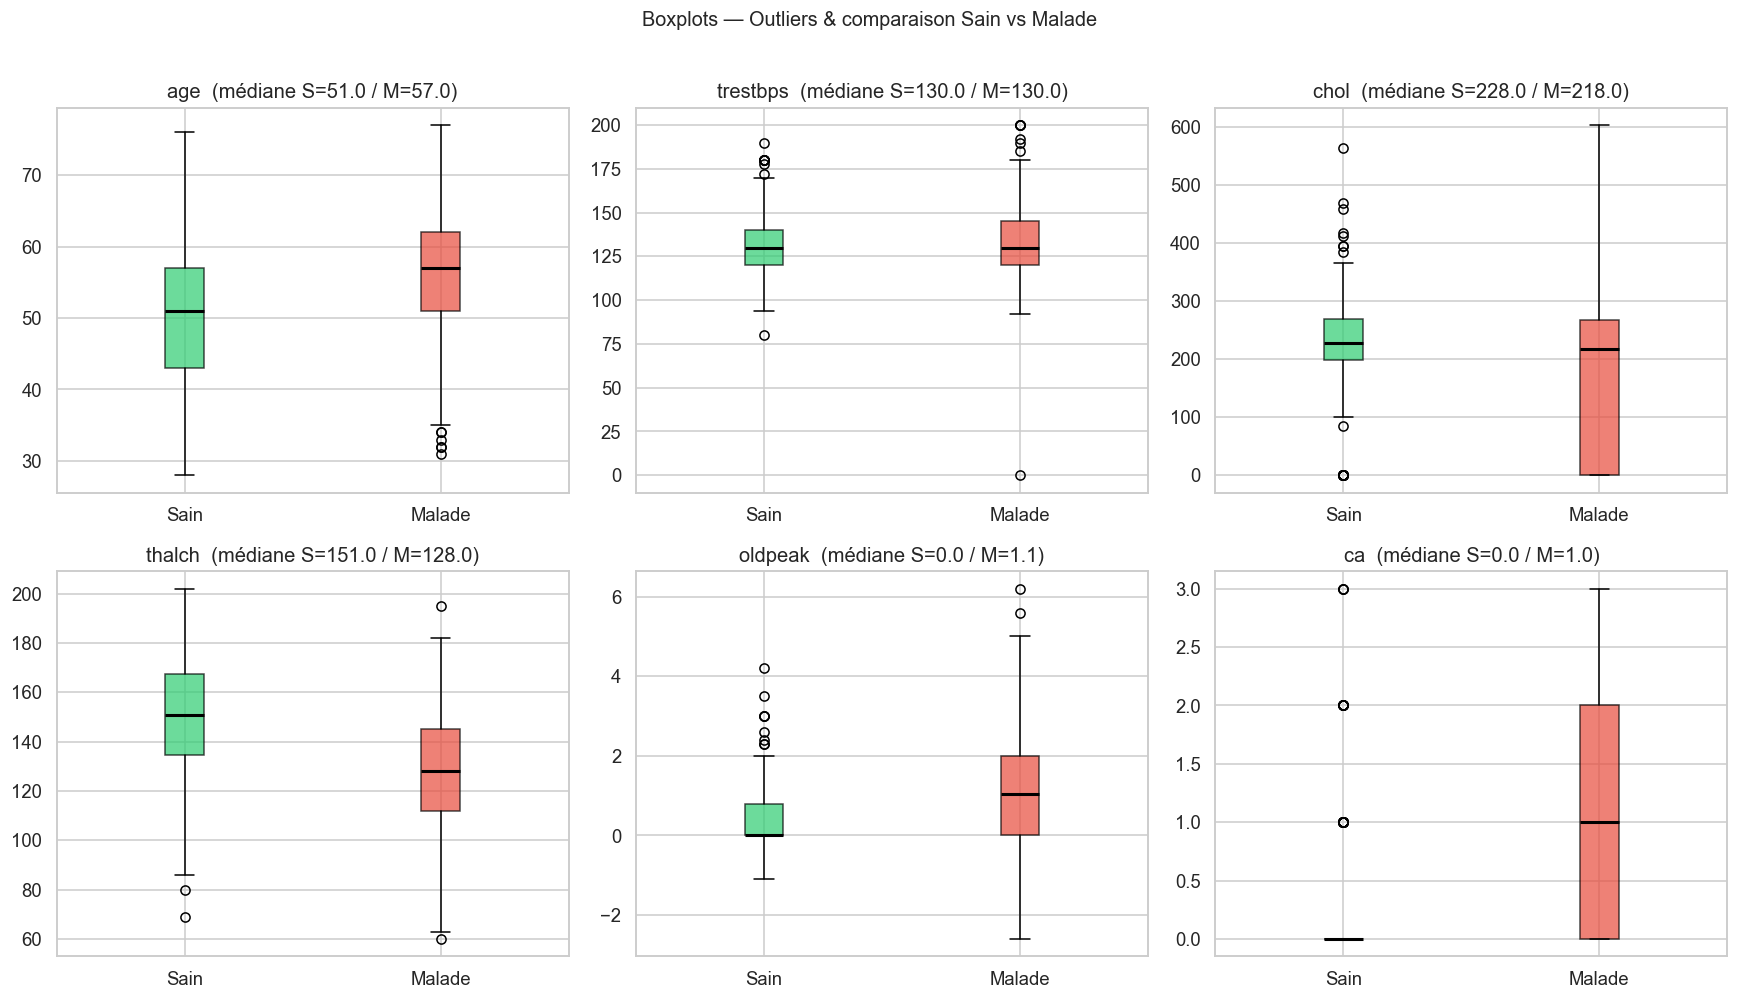

In [6]:
print('=== Valeurs aberrantes ===')
n_chol = (df_raw['chol'] == 0).sum()
n_bps  = (df_raw['trestbps'] == 0).sum()
n_old  = (df_raw['oldpeak'] < 0).sum()
print(f'  chol = 0      → {n_chol} patients  (cholestérol nul = impossible médicalement)')
print(f'  trestbps = 0  → {n_bps} patient   (pression artérielle nulle = impossible)')
print(f'  oldpeak < 0   → {n_old} patients  (dépression ST négative = probablement saisie incorrecte)')

# Boxplots pour voir les outliers
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flat, NUM_COLS):
    data_sain   = df[df['target'] == 0][col].dropna()
    data_malade = df[df['target'] == 1][col].dropna()
    bp = ax.boxplot(
        [data_sain, data_malade],
        labels=['Sain', 'Malade'],
        patch_artist=True,
        medianprops=dict(color='black', linewidth=2)
    )
    bp['boxes'][0].set_facecolor(C['sain'])
    bp['boxes'][0].set_alpha(0.7)
    bp['boxes'][1].set_facecolor(C['malade'])
    bp['boxes'][1].set_alpha(0.7)
    ax.set_title(f'{col}  (médiane S={data_sain.median():.1f} / M={data_malade.median():.1f})')

plt.suptitle('Boxplots — Outliers & comparaison Sain vs Malade', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(FIGS_PATH / '03_boxplots_outliers.png', dpi=150, bbox_inches='tight')
plt.show()